In [1]:
import openseespy.opensees as ops
import matplotlib.pyplot as plt
import opsvis as opsv  # for visualization
import numpy as np
import pandas as pd
import json
import os
from IPython.display import clear_output

from sections import *
from units import *
from utilities import *
from modelBuilder import *

ModuleNotFoundError: No module named 'openseespy'

RSN5668
dt = 0.01


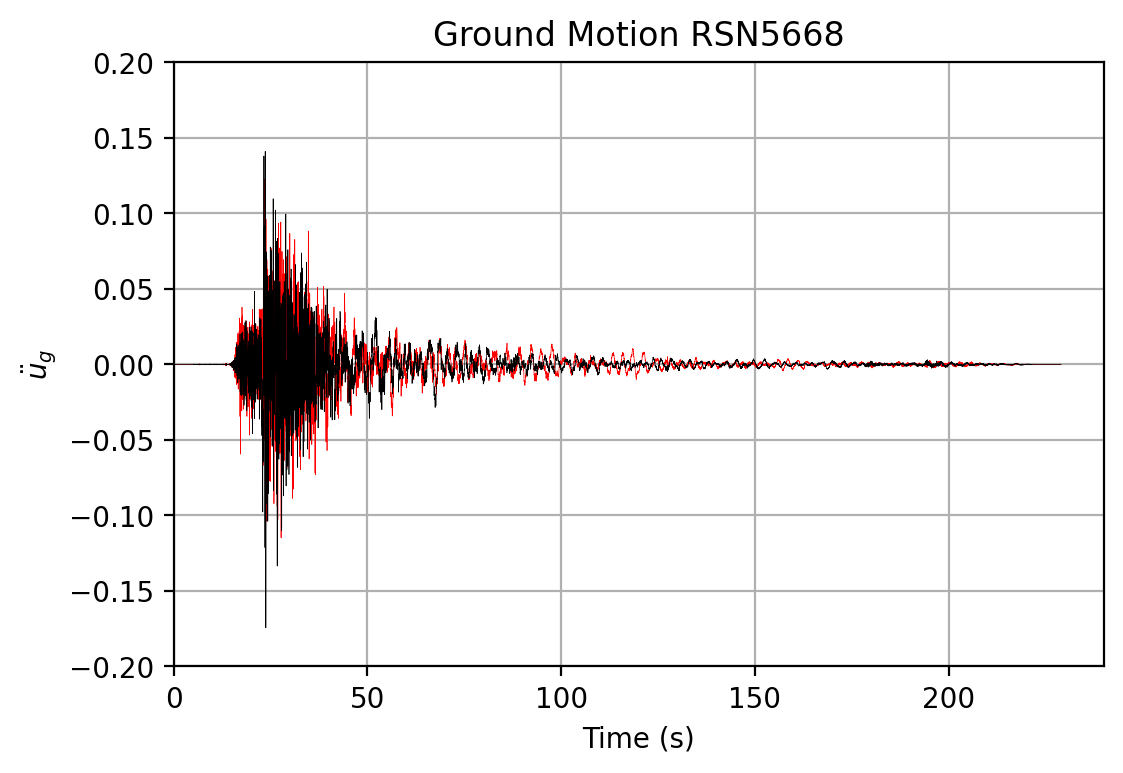

In [2]:
# Select GM
selGM = 4

# Select direction of GM
gmdir = 'x'  # or 'y'

# Open Ground Motion Data
cd = os.getcwd()
gmTable = pd.read_csv("gms//site0.csv")

gmCode = str(selGM).zfill(2) + '_' + gmdir

g = 386
sf = gmTable["factor"][selGM]

print(gmTable["TH_file"][selGM])

with open(cd+"//gms//"+gmTable["TH_file"][selGM]+".json") as file:
    gm_data = json.load(file)
    
gmx = np.array(gm_data["data_x"]) * g * sf
gmy = np.array(gm_data["data_y"]) * g * sf
dt = float(gm_data["dT"])
print("dt =", dt)

gmx = gmx[0:-1:1]
gmy = gmy[0:-1:1]

t = np.arange(0, dt * len(gmx), dt)

plt.figure(dpi=200, figsize=(6,4))
plt.plot(t, gmx/g, 'r', linewidth=0.25)
plt.plot(t, gmy/g, 'k', linewidth=0.25)
plt.grid()
plt.xlabel('Time (s)'), plt.ylabel('$\ddot{u}_g$')
plt.xlim([0, 10 * np.round(max(t) / 10 + 1)])
pga = np.round(np.max(np.abs([gmx, gmy])) / g, 2)
ylim_val = np.ceil(10 * pga) / 10
plt.ylim([-ylim_val, ylim_val])
plt.title('Ground Motion ' + gmTable["TH_file"][selGM])

if gmdir == 'x':
    gm = gmx
elif gmdir == 'y':
    gm = gmy


In [3]:
# Load excel file with model geometry

nodes_df = pd.read_excel("model_geometry.xlsx", sheet_name="nodeInfo")
elements_df = pd.read_excel("model_geometry.xlsx", sheet_name="elements")

In [4]:
# Generate Model
ops.wipe()
ops.model('basic', '-ndm', 3, '-ndf', 6)  # frame 3D

getSections(plot=False)
buildModel(nodes_df, elements_df)

In [5]:
# Run Eigenvalue Analysis

# Perform an eigenvalue analysis
numEigen = 5
eigenValues = ops.eigen(numEigen)
# print("eigen values at start of transient:",eigenValues)
T = 2 * np.pi / np.sqrt(np.array(eigenValues))
print('Periods of identified modes:', T)

# Uncomment to show mode shape
# opsv.plot_mode_shape(1, fig_wi_he=(400., 280.), sfac=1000.0)

Periods of identified modes: [0.39614874 0.34591979 0.34464269 0.33089113 0.32114955]


In [6]:
# Uncomment to plot model
# opsv.plot_model(fig_wi_he=(400., 280.), node_labels=0, element_labels=0, local_axes=0, gauss_points=0)
# plt.savefig("model.pdf")

In [7]:
# Create recorders
# print('running analysis for time:', tCurrent)
nodeTags = []
for nodeID in nodes_df[nodes_df["desc"] == "top of beam"]["nodeID"]:
    nodeTags.append(nodeID)

ops.recorder('Node', '-file', 'node_disp_x_'+gmdir+'.out', '-node', *nodeTags, '-dof', 1, 'disp')
# ops.recorder('Node', '-file', 'node_disp_y_'+gmdir+'.out', '-node', *nodeTags, '-dof', 2, 'disp')

nodeTags = []
for nodeID in nodes_df[nodes_df["desc"] == "base"]["nodeID"]:
    nodeTags.append(nodeID)

ops.recorder('Node', '-file', 'base_disp_x_'+gmdir+'.out', '-node', *nodeTags, '-dof', 1, 'disp')
# ops.recorder('Node', '-file', 'base_disp_y_'+gmdir+'.out', '-node', *nodeTags, '-dof', 2, 'disp')

1

In [ ]:
# Create objects for dynamic analysis

# timeSeries('Path', tag, '-dt', dt=0.0, '-values', *values, '-time', *time, '-filePath', filePath='', '-fileTime', fileTime='', '-factor', factor=1.0, '-startTime', startTime=0.0, '-useLast', '-prependZero')
ops.timeSeries('Path', 1, '-dt', dt, '-values', *gm)

# pattern('UniformExcitation', patternTag, dir, '-disp', dispSeriesTag, '-vel', velSeriesTag, '-accel', accelSeriesTag, '-vel0', vel0, '-fact', fact)
ops.pattern('UniformExcitation', 1, 1, '-accel', 1)

ops.system("BandGeneral")
ops.constraints('Penalty', 1.0, 1.0)
ops.test('NormDispIncr', 1.0e-12,  10)
ops.algorithm("Newton")
ops.numberer('RCM')
ops.integrator('Newmark',  0.5,  0.25)
ops.analysis('Transient')

# set some variables for dynamic analysis
tFinal = len(gmx)*dt
tCurrent = ops.getTime()
ok = 0

time = [tCurrent]
u_top = np.zeros((len(gmx), 65))  # array to store response values (one column per pier)


# Perform the transient analysis
step = 0

while ok == 0 and tCurrent < tFinal:
    step += 1
    ok = ops.analyze(1, dt)
    
    # if the analysis fails try initial tangent iteration
    if ok != 0:
        print("regular newton failed .. lets try an initial stiffness for this step")
        ops.test('NormDispIncr', 1.0e-12,  100, 0)
        ops.algorithm('ModifiedNewton', '-initial')
        ok = ops.analyze(1, dt)
        
        if ok == 0:
            print("that worked .. back to regular newton")
            
        ops.test('NormDispIncr', 1.0e-12,  10)
        ops.algorithm('Newton')
    
    tCurrent = ops.getTime()
    
    if tCurrent > 10 and tCurrent < 10 + dt:
        print(tCurrent)
    
    if tCurrent > 25 and tCurrent < 25 + dt:
        print(tCurrent)
        
    if tCurrent > 45 and tCurrent < 45 + dt:
        print(tCurrent)
        
    if tCurrent > 60 and tCurrent < 60 + dt:
        print(tCurrent)
            
    time.append(tCurrent)

10.009999999999831
25.00000000000111


after: 10 iterations  current Norm: 1.00651e-12 (max: 1e-12, Norm deltaR: 4.70569e-08)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 32.79
OpenSees > analyze failed, returned: -3 error flag


regular newton failed .. lets try an initial stiffness for this step
that worked .. back to regular newton


after: 10 iterations  current Norm: 1.04567e-12 (max: 1e-12, Norm deltaR: 3.3528e-08)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 32.94
OpenSees > analyze failed, returned: -3 error flag


regular newton failed .. lets try an initial stiffness for this step
that worked .. back to regular newton


...

OpenSees > analyze failed, returned: -3 error flag
after: 10 iterations  current Norm: 1.04151e-12 (max: 1e-12, Norm deltaR: 2.64215e-08)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 138.89
OpenSees > analyze failed, returned: -3 error flag
after: 10 iterations  current Norm: 1.14735e-12 (max: 1e-12, Norm deltaR: 2.73493e-08)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 138.9
OpenSees > analyze failed, returned: -3 error flag


regular newton failed .. lets try an initial stiffness for this step
that worked .. back to regular newton
regular newton failed .. lets try an initial stiffness for this step
that worked .. back to regular newton
regular newton failed .. lets try an initial stiffness for this step
that worked .. back to regular newton
regular newton failed .. lets try an initial stiffness for this step


after: 10 iterations  current Norm: 1.26043e-12 (max: 1e-12, Norm deltaR: 2.59049e-08)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 138.91
OpenSees > analyze failed, returned: -3 error flag


that worked .. back to regular newton
regular newton failed .. lets try an initial stiffness for this step
that worked .. back to regular newton


after: 10 iterations  current Norm: 1.31924e-12 (max: 1e-12, Norm deltaR: 3.8063e-08)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 138.92
OpenSees > analyze failed, returned: -3 error flag
after: 10 iterations  current Norm: 1.29488e-12 (max: 1e-12, Norm deltaR: 3.58263e-08)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 138.93
OpenSees > analyze failed, returned: -3 error flag
after: 10 iterations  current Norm: 1.19648e-12 (max: 1e-12, Norm deltaR: 2.21723e-08)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 138.94
OpenSees > analyze failed, returned: -3 error flag
after: 10 iterations  current Norm: 1.07001e-12 (max: 1e-12, Norm deltaR: 2.9158e-08)
NewtonRaphson::solveCurrentStep() -the 

In [ ]:
# nodes_df[nodes_df["desc"] == "top of column"]["nodeID"]

In [ ]:
u_top

In [ ]:
import geopy.distance as geopy

coords_1 = (52.2296756, 21.0122287)
coords_2 = (52.406374, 16.9251681)

print(geopy.geodesic(coords_1, coords_2).miles)

In [ ]:
import utm

p1 = (37.835785, -122.267293)
p2 = (37.835616, -122.267158)

d_gmaps = 71.29 * ft
print(geopy.geodesic(p1, p2).miles * 5280)